In [ ]:
import pandas as pd
import numpy as np
import helper as hp

# CIR

Here we will implement the CIR model as in How to handle negative interest rates in a CIR framework, by M. di Francesco and K. Kamm

In [9]:
# x & y parameters
r0_x, kappa_x, theta_x, sigma_x = 0.030, 0.50, 0.040, 0.10
r0_y, kappa_y, theta_y, sigma_y = 0.025, 0.60, 0.035, 0.12

# Simulation setup
dt = 1/252
T, n_paths = 10.0, 10000

# confidence band, here for 90%
q_lo = 0.05
q_hi = 1 - q_lo

print(f"Parameters of x: r0={r0_x:.2%}, kappa={kappa_x:.3f}, theta={theta_x:.2%}, sigma={sigma_x:.2%}")
print(f"Parameters of y: r0={r0_y:.2%}, kappa={kappa_y:.3f}, theta={theta_y:.2%}, sigma={sigma_y:.2%}")
print(f"Feller(x)= {2*kappa_x*theta_x/sigma_x**2:.3f} | Feller(y)= {2*kappa_y*theta_y/sigma_y**2:.3f}\n")

# Different rng for independence
rng_x = np.random.default_rng(42)
rng_y = np.random.default_rng(314159)

x_paths = hp.cir_simulate(r0_x, kappa_x, theta_x, sigma_x, T, dt, n_paths=n_paths, rng=rng_x)
y_paths = hp.cir_simulate(r0_y, kappa_y, theta_y, sigma_y, T, dt, n_paths=n_paths, rng=rng_y)
z_paths = x_paths - y_paths 

time_grid = np.linspace(0.0, T, x_paths.shape[1])

# Quantile bands
## Exact for x and y, but empirical for z
x_q_lo = hp.cir_quantile_curve(r0_x, kappa_x, theta_x, sigma_x, time_grid, q_lo)
x_q_hi = hp.cir_quantile_curve(r0_x, kappa_x, theta_x, sigma_x, time_grid, q_hi)

y_q_lo = hp.cir_quantile_curve(r0_y, kappa_y, theta_y, sigma_y, time_grid, q_lo)
y_q_hi = hp.cir_quantile_curve(r0_y, kappa_y, theta_y, sigma_y, time_grid, q_hi)

z_q_lo, z_q_hi = np.quantile(z_paths, [q_lo, q_hi], axis=0)  # empirical
x_mean_theory = hp.cir_mean_curve(r0_x, kappa_x, theta_x, time_grid)

Parameters of x: r0=3.00%, kappa=0.500, theta=4.00%, sigma=10.00%
Parameters of y: r0=2.50%, kappa=0.600, theta=3.50%, sigma=12.00%
Feller(x)= 4.000 | Feller(y)= 2.917



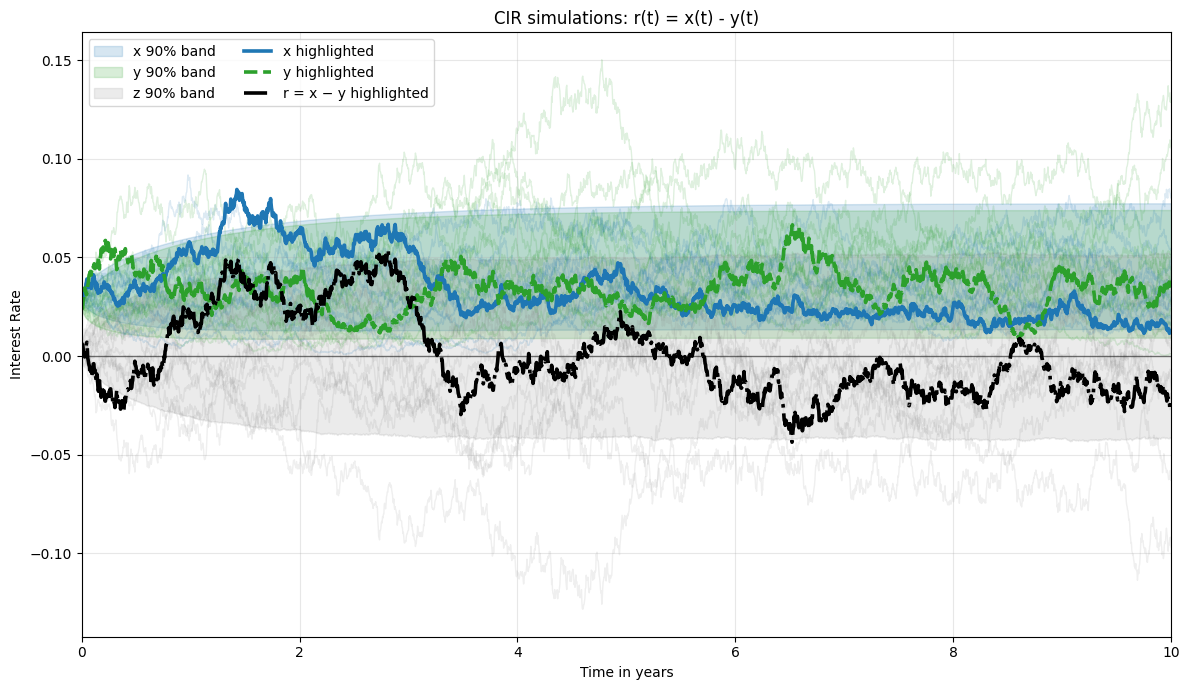

In [ ]:
# Plot x, y and z = x - y
# Highlighted random path in bold, here it is the 1st path.
hp.plot_cir_combined(time_grid, x_paths, y_paths, z_paths,
                  x_q_lo, x_q_hi, y_q_lo, y_q_hi, z_q_lo, z_q_hi)

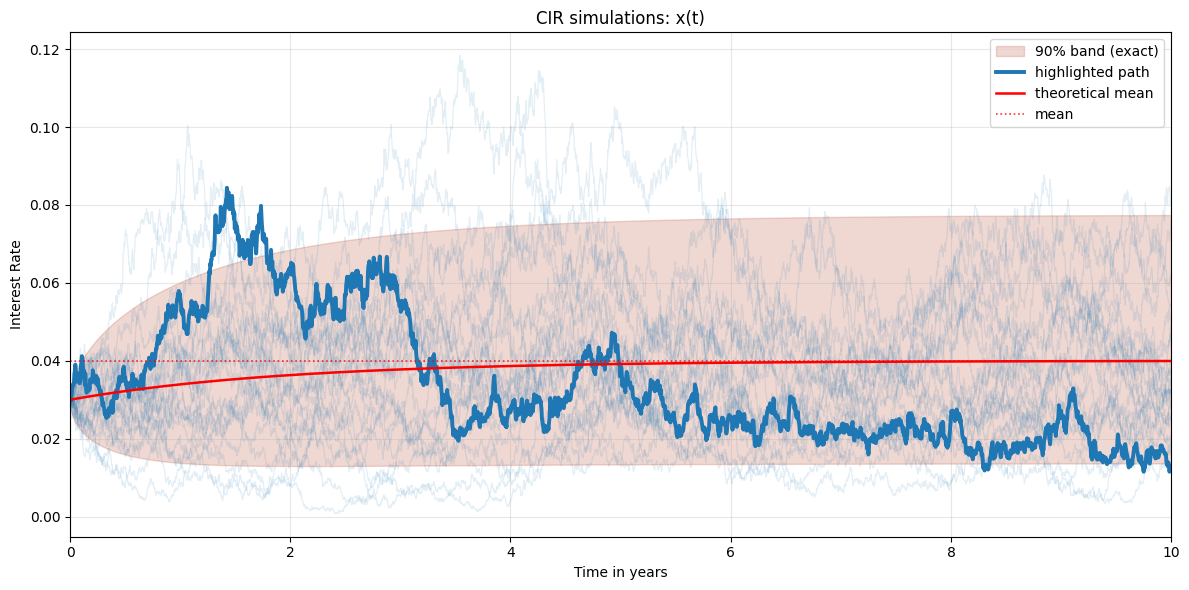

In [ ]:
#Plot only the x process
hp.plot_cir_x_only(time_grid, x_paths, x_q_lo, x_q_hi, x_mean_theory, theta_x)

# Zero coupon Bond

Here we compute the ZCB both analytically and through means of MC

In [10]:
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10], dtype=float)

# Analytical prices
p_ana = np.array([hp.cir_bond_price_analytical(r0_x, kappa_x, theta_x, sigma_x, Tm) for Tm in maturities])

# MC prices reusing simulated x_paths
cum_int = hp.cumulative_trapz_on_grid(x_paths, dt)
grid_times = time_grid

# For each maturity, we snap to the nearest grid point
mc_prices, mc_stderr = [], []
for Tm in maturities:
        k = int(round(Tm / dt))
        k = np.clip(k, 0, grid_times.size - 1)

        # Discount factor per path at Tm
        disc = np.exp(-cum_int[:, k])
        mc_prices.append(np.mean(disc))
        mc_stderr.append(np.std(disc, ddof=1) / np.sqrt(disc.size))

mc_prices = np.array(mc_prices)
mc_stderr = np.array(mc_stderr)

df = pd.DataFrame({
        "T": maturities,
        "P_Analytical": p_ana,
        "P_MC": mc_prices,
        "MC_StdErr": mc_stderr,
        "Abs_Diff": mc_prices - p_ana,
        "Rel_Diff_%": 100.0 * (mc_prices / p_ana - 1.0)
    })

print("\nBond price comparison for x (analytical vs Monte Carlo):")
with pd.option_context("display.float_format", "{:,.6f}".format):
        print(df.to_string(index=False))


Bond price comparison for x (analytical vs Monte Carlo):
        T  P_Analytical     P_MC  MC_StdErr  Abs_Diff  Rel_Diff_%
 0.250000      0.992380 0.992379   0.000012 -0.000001   -0.000055
 0.500000      0.984550 0.984550   0.000032  0.000000    0.000050
 1.000000      0.968415 0.968426   0.000083  0.000010    0.001065
 2.000000      0.935063 0.935258   0.000193  0.000195    0.020826
 3.000000      0.901310 0.901421   0.000297  0.000110    0.012221
 5.000000      0.835234 0.834996   0.000465 -0.000238   -0.028492
 7.000000      0.772838 0.772139   0.000577 -0.000699   -0.090486
10.000000      0.687273 0.686063   0.000675 -0.001210   -0.175997


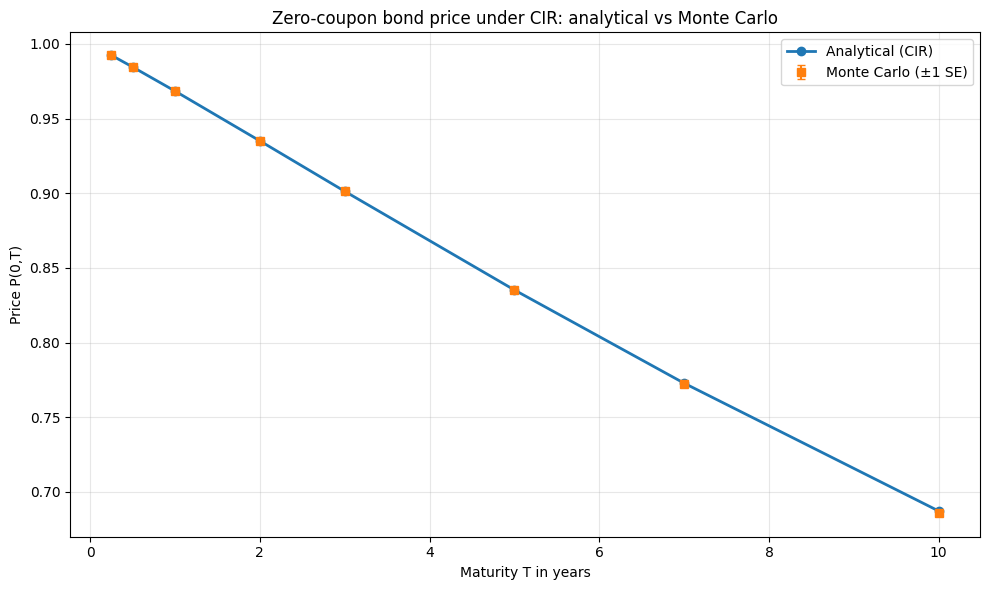

In [7]:
hp.plot_cir_bond_price(
    maturities, p_ana, mc_prices, mc_stderr
)

# Derivative pricing

Additional pricing methods and examples are coming